# Classifying Filipino Text into Complex Emotions

<b><i>Pilot Study version 1</i></b>

The purpose of this notebook is to take a small sub-sample of the combined English dataset to test if the working methodology described below is suitable.

### A. Sub-sampling from the Consolidated Dataset

In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Setup and File Loading

import pandas as pd

FILE_PATH = '/content/drive/MyDrive/AI351Project/Test/Consolidated Emotion Dataset.xlsx'
SELECTED_COLUMNS = ["text", "label", "label_desc"]

# Read the Excel file into a DataFrame, selecting only the required columns
try:
    df = pd.read_excel(
        FILE_PATH,
        usecols=SELECTED_COLUMNS,
        sheet_name="Consolidated Emotion Dataset"
    )

    print(f"DataFrame loaded successfully with {len(df)} rows.")
    print(f"\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {FILE_PATH}")
except ValueError:
    print(f"ERROR: Check the column names. They might not exist in the file: {SELECTED_COLUMNS}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame loaded successfully with 37832 rows.

First 5 rows:
                                                text  label label_desc
0                            i didnt feel humiliated      0    sadness
1  i can go from feeling so hopeless to so damned...      0    sadness
2   im grabbing a minute to post i feel greedy wrong      3      anger
3  i am ever feeling nostalgic about the fireplac...      2       love
4                               i am feeling grouchy      3      anger


## 📊 Initial Class Distribution in Full Dataset


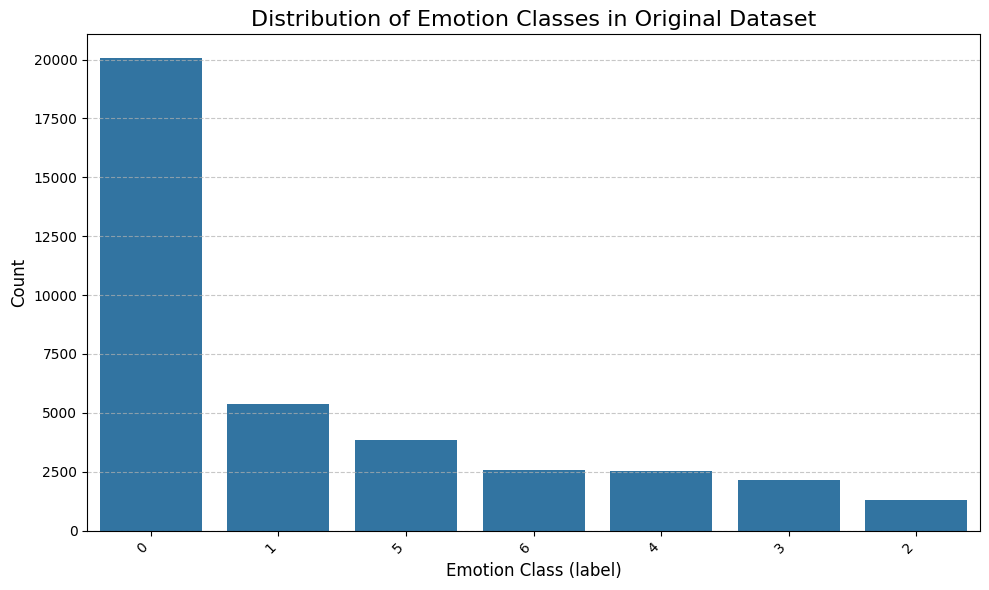

--------------------------------------------------
## ⚖️ Creating Balanced Subsample with N=5 samples per class.

## 📋 Balanced Sampling Report
Original Dataset Size: 37832 rows
----------------------------------------
**Total Number of Samples in Subsample:** 35
**Percentage of Original Data Sampled:** 0.09%

**Samples Per Class in Final Subsample (Guaranteed Equal):**
label
4    5
3    5
1    5
0    5
6    5
2    5
5    5
--------------------------------------------------

Subsampled data successfully saved to **subsample01.csv**
DataFrame for the next step is now **df_subsample**.


In [3]:
# Distribution Analysis, Subsampling, and Reporting

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if this is a new cell

# Show a data distribution of the classes (barchart)
print("## 📊 Initial Class Distribution in Full Dataset")

# Check for balanced/unbalanced classes before sampling
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Emotion Classes in Original Dataset', fontsize=16)
plt.xlabel('Emotion Class (label)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("-" * 50)


N_PER_CLASS = 5

min_count_full = df['label'].value_counts().min()

if N_PER_CLASS > min_count_full:
    print(f"⚠️ WARNING: The requested N_PER_CLASS ({N_PER_CLASS}) exceeds the smallest class size ({min_count_full}).")
    print(f"   To avoid errors, N_PER_CLASS is being set to the maximum possible count: **{min_count_full}**.")
    N_PER_CLASS = min_count_full

print(f"## ⚖️ Creating Balanced Subsample with N={N_PER_CLASS} samples per class.")

balanced_samples = []
# Iterate through each unique class (label)
for label in df['label'].unique():
    # Filter the DataFrame for the current class
    class_df = df[df['label'] == label]

    # Randomly sample the fixed number (N_PER_CLASS)
    sampled_df = class_df.sample(n=N_PER_CLASS, random_state=42)

    balanced_samples.append(sampled_df)

# Combine all the equal-sized sampled DataFrames
df_subsample = pd.concat(balanced_samples).reset_index(drop=True)

# Shuffle the final DataFrame rows to mix the class order
df_subsample = df_subsample.sample(frac=1, random_state=131).reset_index(drop=True)


# Report the metrics
total_original = len(df)
total_sampled = len(df_subsample)
sampled_percentage = (total_sampled / total_original) * 100
samples_per_class = df_subsample['label'].value_counts()

print(f"\n## 📋 Balanced Sampling Report")
print(f"Original Dataset Size: {total_original} rows")
print(f"----------------------------------------")
print(f"**Total Number of Samples in Subsample:** {total_sampled}")
print(f"**Percentage of Original Data Sampled:** {sampled_percentage:.2f}%")
print(f"\n**Samples Per Class in Final Subsample (Guaranteed Equal):**")
# This should show MIN_COUNT for every class
print(samples_per_class.to_string())

print("-" * 50)

# This will be saved as a CSV called “subsample01.csv”
OUTPUT_FILENAME = "subsample01.csv"
try:
    df_subsample.to_csv(OUTPUT_FILENAME, index=False)
    print(f"\nSubsampled data successfully saved to **{OUTPUT_FILENAME}**")
    print(f"DataFrame for the next step is now **df_subsample**.")
except Exception as e:
    print(f"ERROR during CSV save: {e}")

###B. Machine Translation using Language Models

In [4]:
# Loading the Sub-Sample

FILE_PATH2 = FILE_PATH = '/content/drive/MyDrive/AI351Project/Test/subsample01.csv'
SELECTED_COLUMNS2 = ["text", "label", "label_desc"]

# Read the File into a DataFrame, selecting only the required columns
try:
    df_sub = pd.read_csv(
        FILE_PATH2,
        usecols=SELECTED_COLUMNS2,
        encoding="latin1"
    )

    print(f"DataFrame loaded successfully with {len(df_sub)} rows.")
    print(f"\nFirst 5 rows:")
    display(df_sub)

except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {FILE_PATH2}")
except ValueError:
    print(f"ERROR: Check the column names. They might not exist in the file: {SELECTED_COLUMNS2}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame loaded successfully with 35 rows.

First 5 rows:


,text,label,label_desc
0,i feel shy to him all the time,4,fear
1,i feel frustrated sometimes with my mac lipsti...,3,anger
2,im feeling much more positive about the impend...,1,joy
3,what is wrong with meI just suddenly had this ...,0,sadness
4,This question sounds real dumb to even myself ...,0,sadness
5,i feel more irritable and i feel more sensible...,3,anger
6,i feel im rather innocent in that respect,1,joy
7,as a child i suffered of nightmares even since...,4,fear
8,So he hasn't really hit me since we got back t...,6,stress
9,i feel like i am meant to partner up be suppor...,2,love


In [5]:
# Installing Dependencies

!nvidia-smi
!pip install transformers accelerate sentencepiece --quiet

Fri Dec  5 02:32:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   34C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# Load the SLM (SEA-LION)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "aisingapore/Gemma-SEA-LION-v3-9B-IT"  # SLM of choice

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.57G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [7]:
# Define a Machine Translation Prompt
def build_prompt(text):
    return (
        "You are a translation engine. "
        "Translate the text into natural and standard Filipino. "
        "Maintain the original meaning, tone, and emotional content. "
        "Do not explain, summarize, rewrite, or add any commentary. "
        "Output only the translated sentence.\n\n"
        f"Text: {text}\n"
        "Translation:"
    )


In [8]:
# Batched Translation Function
def translate_batch(text_list, batch_size=32):
    translations = []

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]

        prompts = [build_prompt(t) for t in batch]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=120,
                do_sample=False,    # deterministic MT
                temperature=0.0
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        # Extract translations cleanly
        clean = []
        for txt in decoded:
            if "Translation:" in txt:
                txt = txt.split("Translation:")[-1].strip()
            clean.append(txt)

        translations.extend(clean)

    return translations

In [9]:
# Perform Machine Translation to Subsample
texts = df_sub["text"].tolist()

translations = translate_batch(texts, batch_size=1)

df_sub_mt = df_sub.copy()
df_sub_mt["translation"] = translations

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [10]:
# Save Output CSV
df_sub_mt.to_csv("subsample01_mt.csv", index=False)
print("Saved as subsample01_mt.csv")
df_sub_mt.head()

Saved as subsample01_mt.csv


,text,label,label_desc,translation
0,i feel shy to him all the time,4,fear,Lagi akong nahihiya sa kanya.
1,i feel frustrated sometimes with my mac lipsti...,3,anger,"Minsan, naiirita ako sa aking mga MAC lipstick..."
2,im feeling much more positive about the impend...,1,joy,Mas positibo na ako tungkol sa paparating na p...
3,what is wrong with meI just suddenly had this ...,0,sadness,Ano ba ang mali sa akin? Biglang dumating iton...
4,This question sounds real dumb to even myself ...,0,sadness,Mukhang bobo nga itong tanong na ito kahit ako...


Performing Metric Check

In [3]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


In [4]:
# 1) Clone repo (if not already)
!git clone https://github.com/google-research/metricx.git || true

# 2) Install common dependencies MetricX needs (transformers/datasets/etc)
!pip install -q transformers datasets sentencepiece sacremoses

# 3) Set PYTHONPATH so Python can import metricx24 package directly
import os
os.environ['PYTHONPATH'] = '/content/metricx'

# 4) (Optional) verify the module is importable
!python -c "import metricx24; print('metricx24 import OK')"


Cloning into 'metricx'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 26 (delta 7), reused 2 (delta 2), pack-reused 12 (from 1)
Receiving objects: 100% (26/26), 20.76 KiB | 20.76 MiB/s, done.
Resolving deltas: 100% (10/10), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 50.1 MB/s eta 0:00:00
metricx24 import OK


In [5]:
!python -m metricx24.predict \
  --tokenizer google/metricx-24-qe-base \
  --model_name_or_path google/metricx-24-qe-base \
  --max_input_length 512 \
  --batch_size 4 \
  --input_file metricx_input_qe.jsonl \
  --output_file metricx_preds_qe.jsonl \
  --qe True


2025-12-05 03:09:17.644124: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 03:09:17.663981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764904157.686411    1729 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764904157.692934    1729 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764904157.710753    1729 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 